# Red Neuronal con Fashion MNIST - Clasificación Multiclase

Este cuaderno implementa diferentes arquitecturas de redes neuronales para clasificar imágenes del dataset Fashion MNIST.

## Dataset Fashion MNIST
- 70,000 imágenes en escala de grises de 28x28 píxeles
- 10 clases de prendas de vestir:
  - 0: T-shirt/top
  - 1: Trouser
  - 2: Pullover
  - 3: Dress
  - 4: Coat
  - 5: Sandal
  - 6: Shirt
  - 7: Sneaker
  - 8: Bag
  - 9: Ankle boot

c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Cargando dataset Fashion MNIST...

Forma de los datos de entrenamiento: (60000, 28, 28)
Forma de los datos de test: (10000, 28, 28)
Forma de las etiquetas de entrenamiento: (60000,)
Forma de las etiquetas de test: (10000,)

Rango de valores de píxeles: [0, 255]
Número de clases: 10

Distribución de clases en el conjunto de entrenamiento:
  0 (T-shirt/top): 6000 imágenes (10.00%)
  1 (Trouser): 6000 imágenes (10.00%)
  2 (Pullover): 6000 imágenes (10.00%)
  3 (Dress): 6000 imágenes (10.00%)
  4 (Coat): 6000 imágenes (10.00%)
  5 (Sandal): 6000 imágenes (10.00%)
  6 (Shirt): 6000 imágenes (10.00%)
  7 (Sneaker): 6000 imágenes (10.00%)
  8 (Bag): 6000 imágenes (10.00%)
  9 (Ankle boot): 6000 imágenes (10.00%)


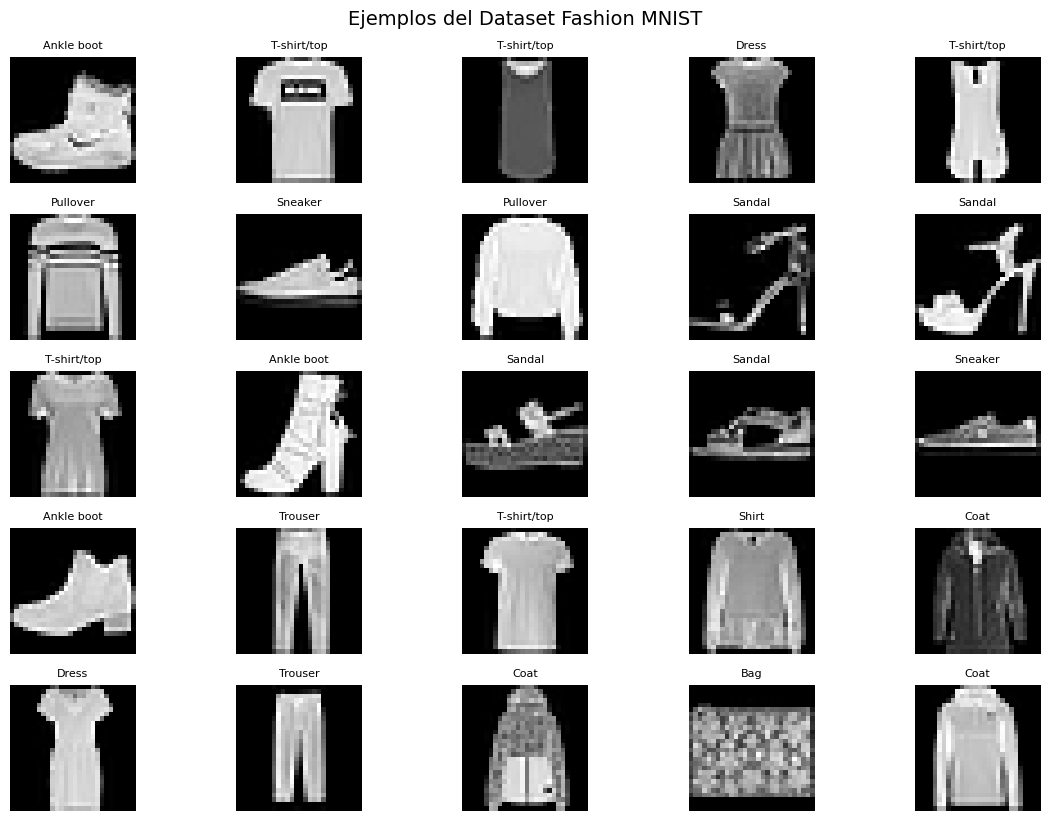


INFORMACIÓN DEL DATASET
Total de imágenes de entrenamiento: 60000
Total de imágenes de test: 10000
Dimensiones de cada imagen: 28x28 píxeles
Total de características por imagen: 784 píxeles
Número de clases: 10

NOTA: Fashion MNIST es un dataset de clasificación multiclase con 10 categorías.
Las imágenes están en escala de grises (0-255).


In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam, SGD, RMSprop
from keras.callbacks import EarlyStopping

# Configuración
np.random.seed(42)
tf.random.set_seed(42)

# Cargar el dataset Fashion MNIST
print("Cargando dataset Fashion MNIST...")
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Convertir etiquetas a one-hot encoding para el modelo
y_train_cat = keras.utils.to_categorical(y_train_full, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"\nForma de los datos de entrenamiento: {X_train_full.shape}")
print(f"Forma de los datos de test: {X_test.shape}")
print(f"Forma de las etiquetas de entrenamiento: {y_train_full.shape}")
print(f"Forma de las etiquetas de test: {y_test.shape}")

print(f"\nRango de valores de píxeles: [{X_train_full.min()}, {X_train_full.max()}]")
print(f"Número de clases: {len(class_names)}")

# Mostrar distribución de clases
print("\nDistribución de clases en el conjunto de entrenamiento:")
unique, counts = np.unique(y_train_full, return_counts=True)
for i, (clase, count) in enumerate(zip(unique, counts)):
    print(f"  {clase} ({class_names[clase]}): {count} imágenes ({count/len(y_train_full)*100:.2f}%)")

# Visualizar algunas imágenes de ejemplo
plt.figure(figsize=(12, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Ejemplos del Dataset Fashion MNIST', y=1.02, fontsize=14)
plt.show()

print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Total de imágenes de entrenamiento: {len(X_train_full)}")
print(f"Total de imágenes de test: {len(X_test)}")
print(f"Dimensiones de cada imagen: 28x28 píxeles")
print(f"Total de características por imagen: {28*28} píxeles")
print(f"Número de clases: {len(class_names)}")
print("\nNOTA: Fashion MNIST es un dataset de clasificación multiclase con 10 categorías.")
print("Las imágenes están en escala de grises (0-255).")

RED NEURONAL PARA CLASIFICACIÓN DE FASHION MNIST
Configuración: Entrada de imágenes 28x28
Arquitectura: Flatten -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(10, softmax)

Forma de X_train_img: (48000, 28, 28)
Forma de X_val_img: (12000, 28, 28)
Forma de X_test_img: (10000, 28, 28)


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7743 - loss: 0.6306 - val_accuracy: 0.8406 - val_loss: 0.4298
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8405 - loss: 0.4388 - val_accuracy: 0.8520 - val_loss: 0.3952
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8545 - loss: 0.3973 - val_accuracy: 0.8586 - val_loss: 0.3724
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8630 - loss: 0.3752 - val_accuracy: 0.8654 - val_loss: 0.3581
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8694 - loss: 0.3533 - val_accuracy: 0.8754 - val_loss: 0.3417
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8750 - loss: 0.3397 - val_accuracy: 0.8756 - val_loss: 0.3369
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8786 - loss: 0.3248 - val_accuracy: 0.8803 - val_loss: 0.3331
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8825 - l

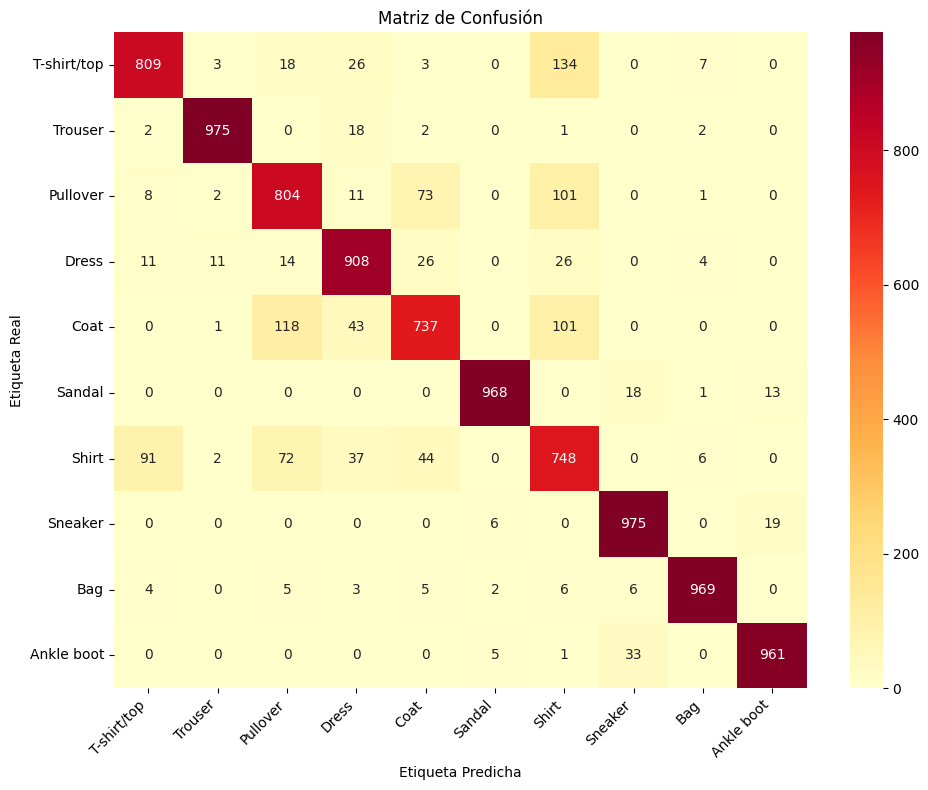

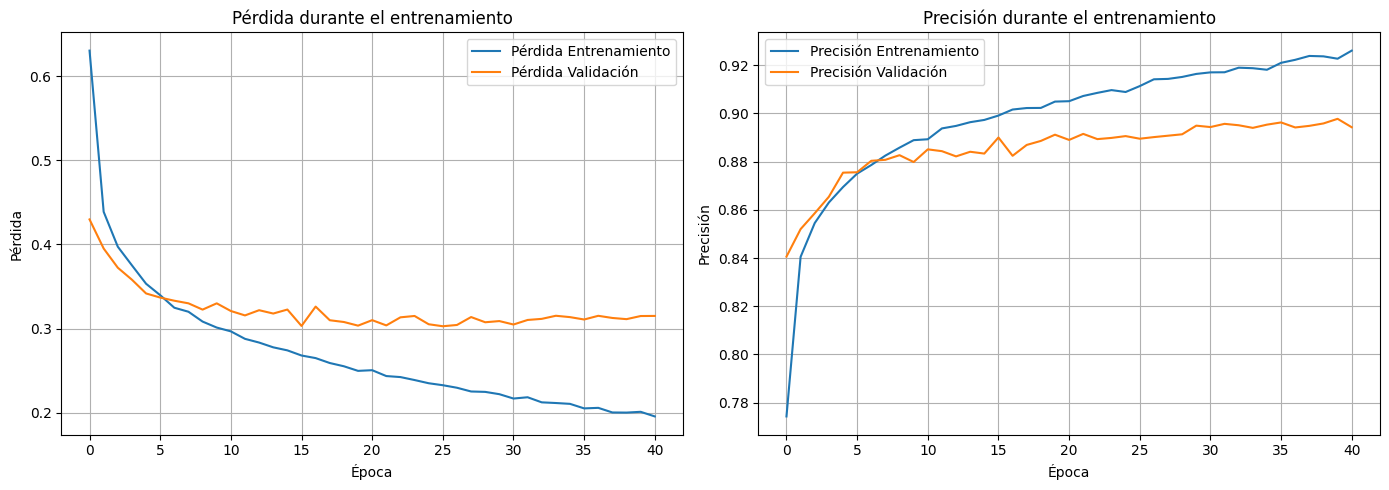


Modelo entrenado exitosamente.


In [2]:
# Red Neuronal con Flatten layer y arquitectura mejorada
print("="*80)
print("RED NEURONAL PARA CLASIFICACIÓN DE FASHION MNIST")
print("="*80)
print("Configuración: Entrada de imágenes 28x28")
print("Arquitectura: Flatten -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(10, softmax)")
print("="*80 + "\n")

# Para este modelo, usaremos las imágenes sin aplanar
X_train_img = X_train_full[:int(len(X_train_full)*0.8)]
X_val_img = X_train_full[int(len(X_train_full)*0.8):]
y_train_img = y_train_cat[:int(len(y_train_cat)*0.8)]
y_val_img = y_train_cat[int(len(y_train_cat)*0.8):]

# Normalizar
X_train_img = X_train_img / 255.0
X_val_img = X_val_img / 255.0
X_test_img = X_test / 255.0

print(f"Forma de X_train_img: {X_train_img.shape}")
print(f"Forma de X_val_img: {X_val_img.shape}")
print(f"Forma de X_test_img: {X_test_img.shape}")

# Construcción del modelo con Flatten
model = Sequential([
    Flatten(input_shape=(28, 28), name='flatten'),
    Dense(256, activation='relu', name='hidden_layer_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(128, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    Dense(10, activation='softmax', name='output_layer')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model.summary()

# Entrenamiento con early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history = model.fit(X_train_img, y_train_img,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val_img, y_val_img),
                        callbacks=[early_stop],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss, test_accuracy = model.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Precisión en test: {test_accuracy:.4f}")

# Predicciones
y_pred = model.predict(X_test_img, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes, y_pred_classes):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes, y_pred_classes, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names, zero_division=0))

# Matriz de confusión
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nModelo entrenado exitosamente.")

VISUALIZACIÓN DE PREDICCIONES



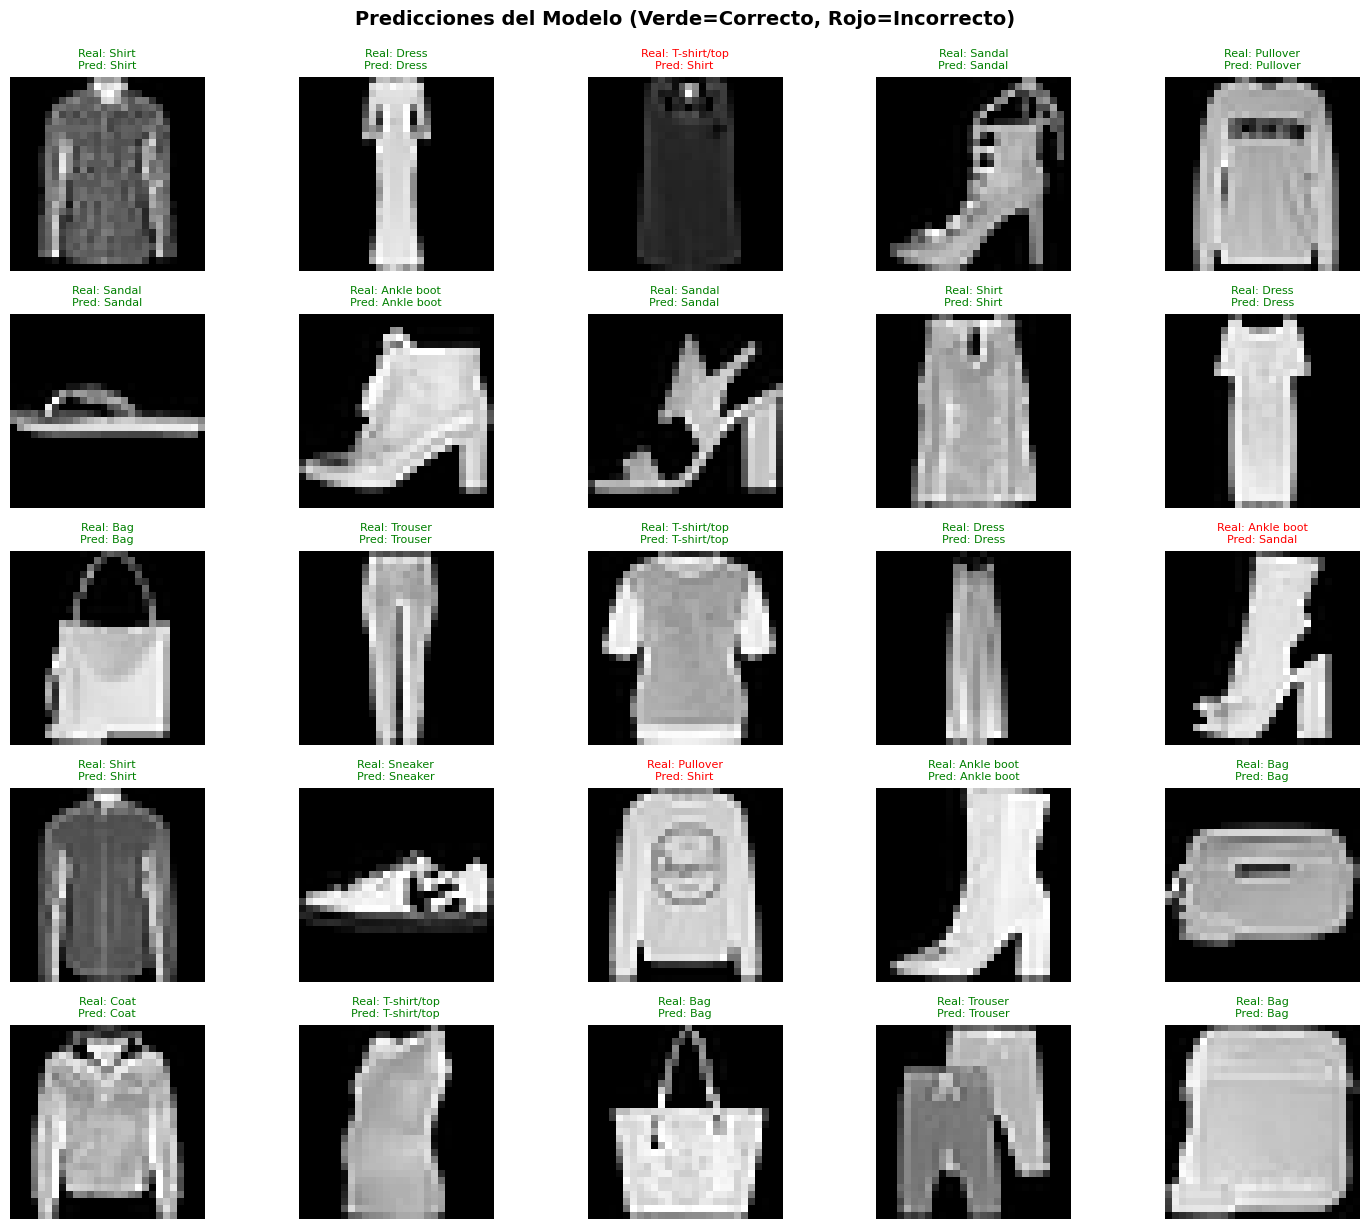


Buscando predicciones incorrectas...
Total de predicciones incorrectas: 1146 de 10000
Porcentaje de error: 11.46%


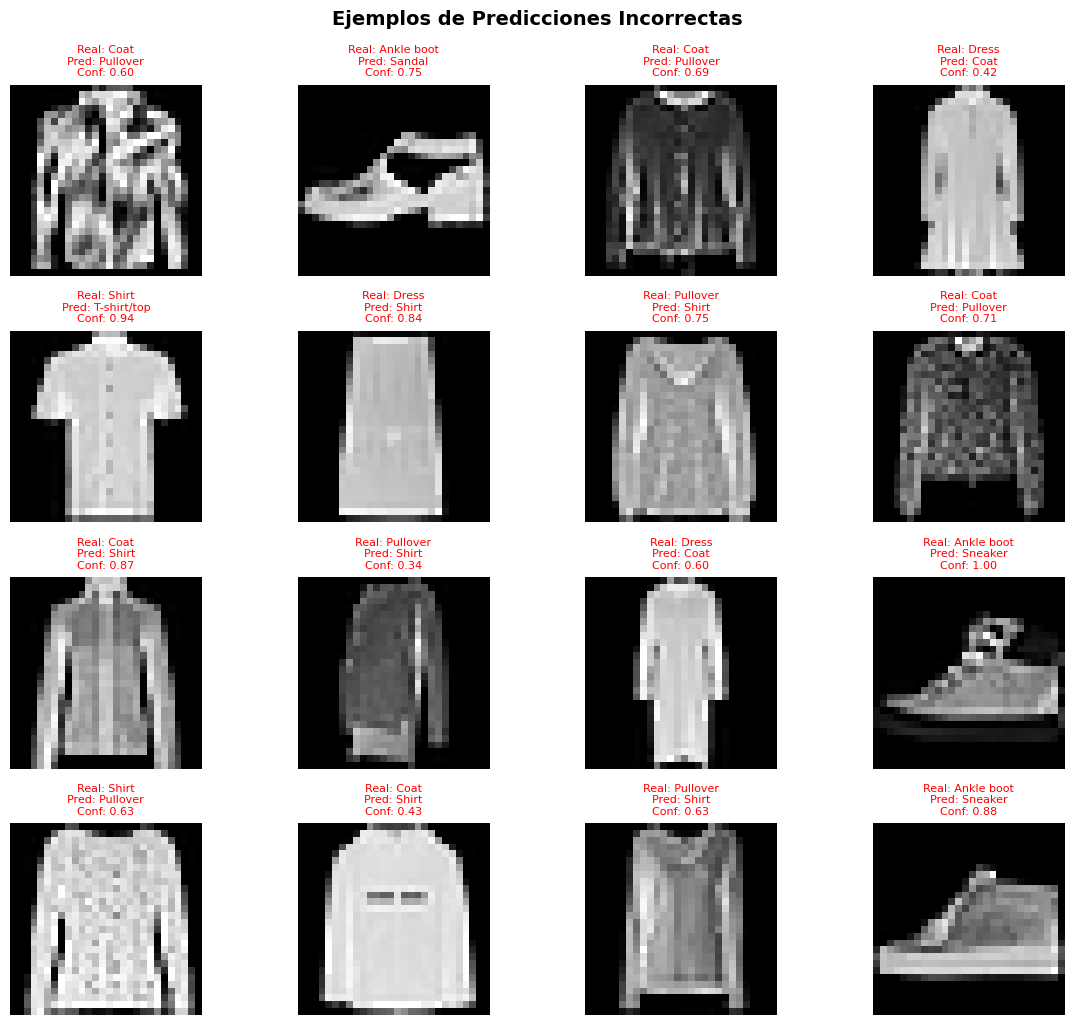

In [3]:
# Visualización de predicciones
print("="*80)
print("VISUALIZACIÓN DE PREDICCIONES")
print("="*80 + "\n")

# Seleccionar algunas imágenes de prueba aleatoriamente
np.random.seed(42)
indices_aleatorios = np.random.choice(len(X_test), 25, replace=False)

# Hacer predicciones
predicciones_visualizar = model.predict(X_test_img[indices_aleatorios], verbose=0)
clases_predichas_vis = np.argmax(predicciones_visualizar, axis=1)
clases_reales_vis = y_test[indices_aleatorios]

# Visualizar las predicciones
plt.figure(figsize=(15, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[indices_aleatorios[i]], cmap='gray')
    
    # Color verde si es correcto, rojo si es incorrecto
    color = 'green' if clases_predichas_vis[i] == clases_reales_vis[i] else 'red'
    
    plt.title(f'Real: {class_names[clases_reales_vis[i]]}\n'
              f'Pred: {class_names[clases_predichas_vis[i]]}',
              fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Predicciones del Modelo (Verde=Correcto, Rojo=Incorrecto)', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Mostrar algunas predicciones incorrectas
print("\nBuscando predicciones incorrectas...")
indices_incorrectos = np.where(y_pred_classes != y_test)[0]
print(f"Total de predicciones incorrectas: {len(indices_incorrectos)} de {len(y_test)}")
print(f"Porcentaje de error: {len(indices_incorrectos)/len(y_test)*100:.2f}%")

# Visualizar algunas predicciones incorrectas
if len(indices_incorrectos) > 0:
    num_mostrar = min(16, len(indices_incorrectos))
    indices_mostrar = indices_incorrectos[:num_mostrar]
    
    plt.figure(figsize=(12, 10))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_probs = y_pred[idx]
        pred_class = y_pred_classes[idx]
        real_class = y_test[idx]
        
        plt.title(f'Real: {class_names[real_class]}\n'
                  f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {pred_probs[pred_class]:.2f}',
                  fontsize=8, color='red')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle('Ejemplos de Predicciones Incorrectas', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("¡Increíble! No hay predicciones incorrectas.")

ANÁLISIS DE CONFIANZA DE PREDICCIONES

Confianza promedio: 0.9010
Confianza promedio en predicciones correctas: 0.9319
Confianza promedio en predicciones incorrectas: 0.6623


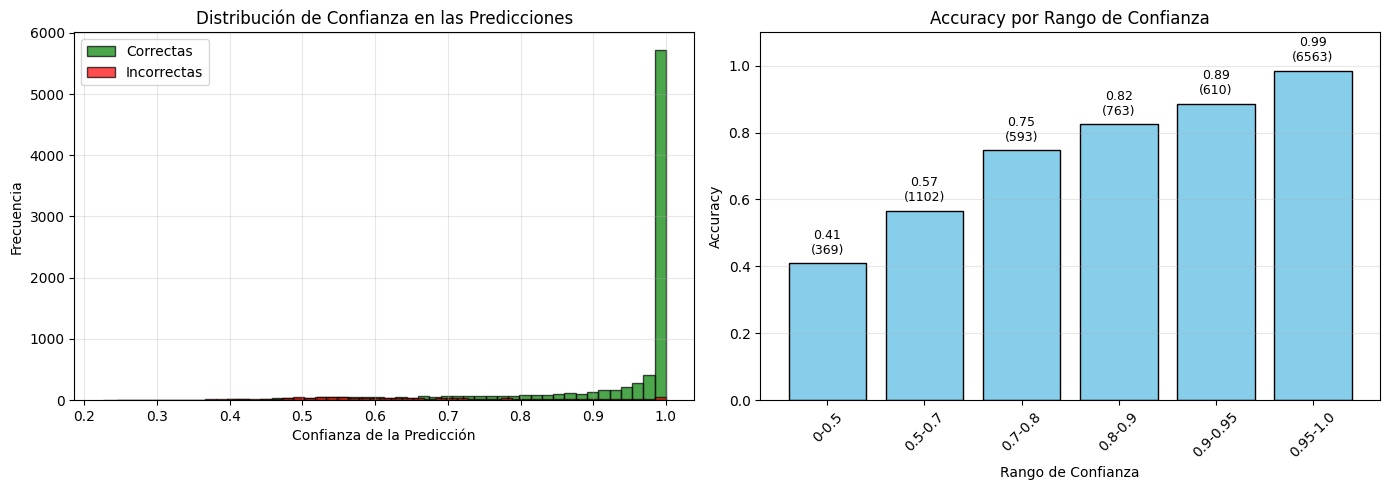


Predicciones con alta confianza (>0.9) pero incorrectas:
Total: 166


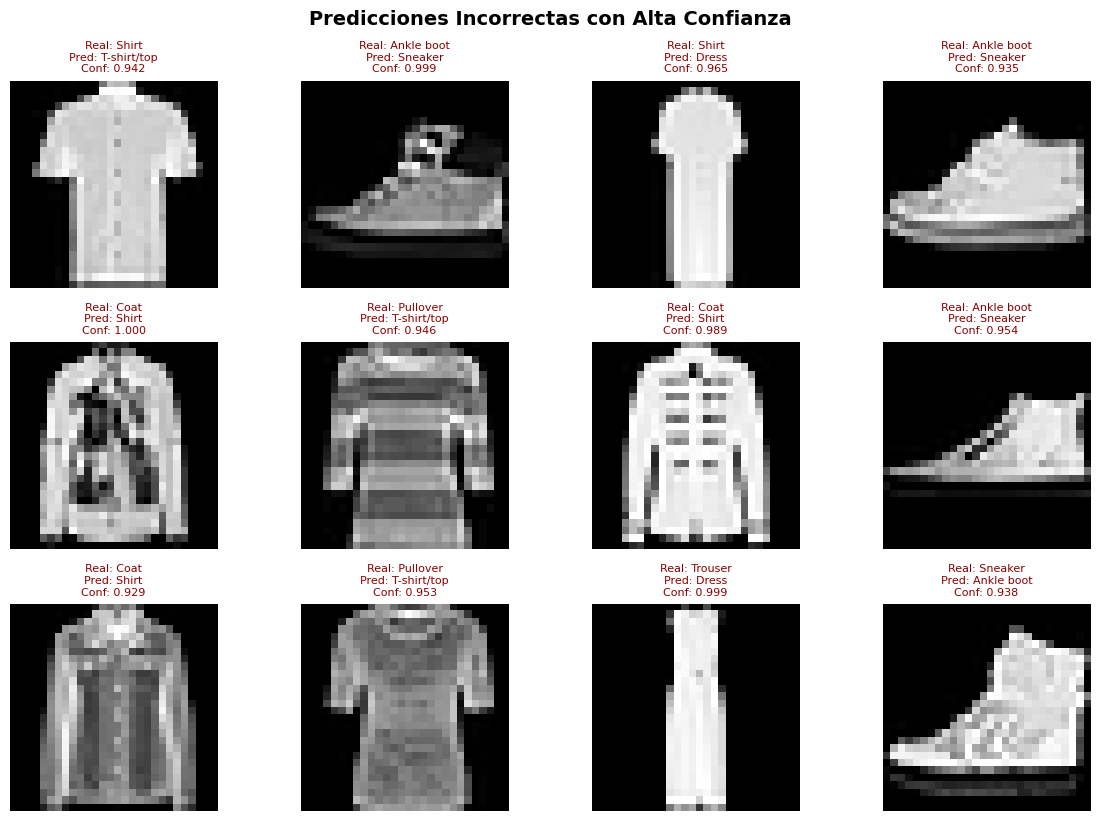

In [4]:
# Análisis de confianza de las predicciones
print("="*80)
print("ANÁLISIS DE CONFIANZA DE PREDICCIONES")
print("="*80 + "\n")

# Obtener probabilidades de predicción
probabilidades = y_pred
confianzas = np.max(probabilidades, axis=1)
predicciones = y_pred_classes
correctas = predicciones == y_test

print(f"Confianza promedio: {confianzas.mean():.4f}")
print(f"Confianza promedio en predicciones correctas: {confianzas[correctas].mean():.4f}")
print(f"Confianza promedio en predicciones incorrectas: {confianzas[~correctas].mean():.4f}")

# Distribución de confianzas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(confianzas[correctas], bins=50, alpha=0.7, label='Correctas', color='green', edgecolor='black')
plt.hist(confianzas[~correctas], bins=50, alpha=0.7, label='Incorrectas', color='red', edgecolor='black')
plt.xlabel('Confianza de la Predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de Confianza en las Predicciones')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
bins_conf = [0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
labels_conf = ['0-0.5', '0.5-0.7', '0.7-0.8', '0.8-0.9', '0.9-0.95', '0.95-1.0']

for i in range(len(bins_conf)-1):
    mask = (confianzas >= bins_conf[i]) & (confianzas < bins_conf[i+1])
    if i == len(bins_conf)-2:  # último bin incluye 1.0
        mask = (confianzas >= bins_conf[i]) & (confianzas <= bins_conf[i+1])
    
    total_bin = mask.sum()
    correctas_bin = (mask & correctas).sum()
    
    if total_bin > 0:
        acc_bin = correctas_bin / total_bin
        plt.bar(i, acc_bin, color='skyblue', edgecolor='black')
        plt.text(i, acc_bin + 0.02, f'{acc_bin:.2f}\n({total_bin})', 
                ha='center', va='bottom', fontsize=9)

plt.xlabel('Rango de Confianza')
plt.ylabel('Accuracy')
plt.title('Accuracy por Rango de Confianza')
plt.xticks(range(len(labels_conf)), labels_conf, rotation=45)
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar predicciones con alta confianza pero incorrectas
print("\nPredicciones con alta confianza (>0.9) pero incorrectas:")
alta_confianza_incorrecta = np.where((confianzas > 0.9) & (~correctas))[0]
print(f"Total: {len(alta_confianza_incorrecta)}")

if len(alta_confianza_incorrecta) > 0:
    num_mostrar = min(12, len(alta_confianza_incorrecta))
    
    plt.figure(figsize=(12, 8))
    for i in range(num_mostrar):
        idx = alta_confianza_incorrecta[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_class = predicciones[idx]
        real_class = y_test[idx]
        conf = confianzas[idx]
        
        plt.title(f'Real: {class_names[real_class]}\n'
                  f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {conf:.3f}',
                  fontsize=8, color='darkred')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle('Predicciones Incorrectas con Alta Confianza', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("No hay predicciones incorrectas con confianza > 0.9")

ANÁLISIS DE RENDIMIENTO POR CLASE

      Clase  Precisión  Recall  F1-Score  Muestras
T-shirt/top   0.874595   0.809  0.840519      1000
    Trouser   0.980885   0.975  0.977934      1000
   Pullover   0.779825   0.804  0.791728      1000
      Dress   0.868069   0.908  0.887586      1000
       Coat   0.828090   0.737  0.779894      1000
     Sandal   0.986748   0.968  0.977284      1000
      Shirt   0.669052   0.748  0.706327      1000
    Sneaker   0.944767   0.975  0.959646      1000
        Bag   0.978788   0.969  0.973869      1000
 Ankle boot   0.967774   0.961  0.964375      1000


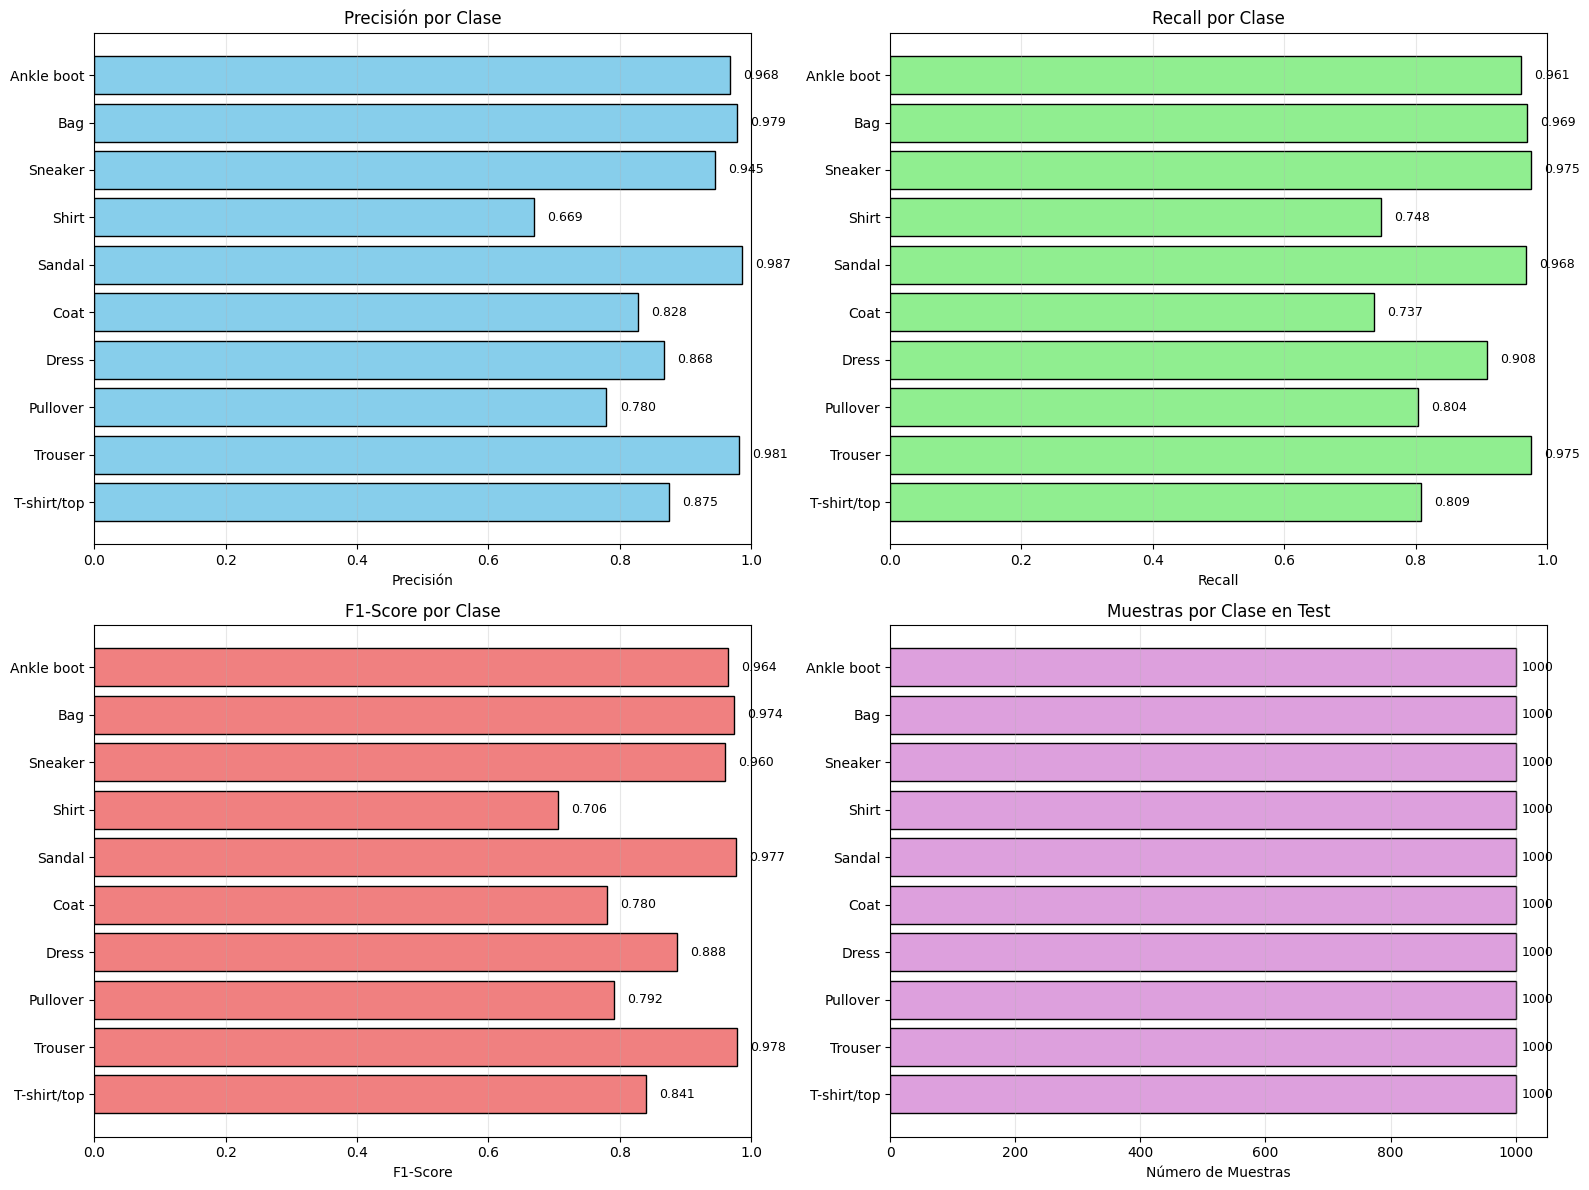


MEJOR CLASE: Trouser
  F1-Score: 0.9779
  Precisión: 0.9809
  Recall: 0.9750

PEOR CLASE: Shirt
  F1-Score: 0.7063
  Precisión: 0.6691
  Recall: 0.7480

Ejemplos de la clase más difícil (Shirt):


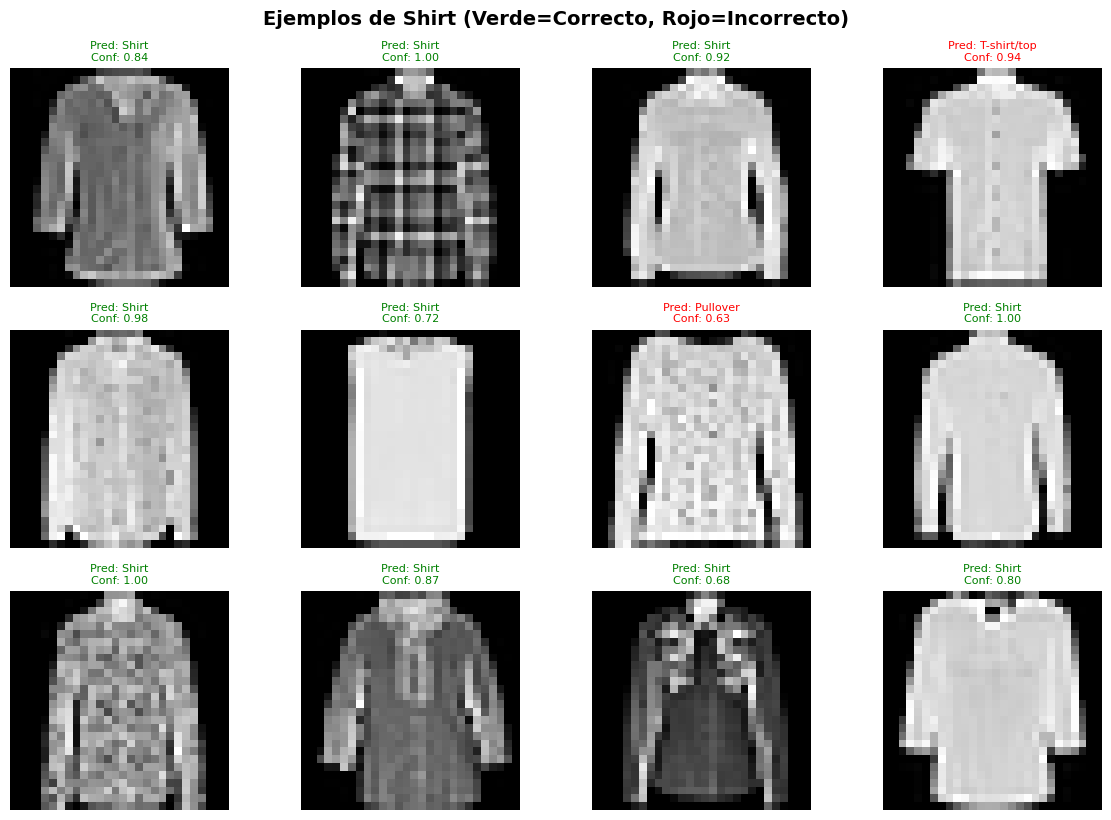

In [5]:
# Análisis de rendimiento por clase
print("="*80)
print("ANÁLISIS DE RENDIMIENTO POR CLASE")
print("="*80 + "\n")

# Calcular métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision_por_clase, recall_por_clase, f1_por_clase, support_por_clase = precision_recall_fscore_support(
    y_test, y_pred_classes, average=None, zero_division=0
)

# Crear DataFrame con las métricas
df_por_clase = pd.DataFrame({
    'Clase': class_names,
    'Precisión': precision_por_clase,
    'Recall': recall_por_clase,
    'F1-Score': f1_por_clase,
    'Muestras': support_por_clase
})

print(df_por_clase.to_string(index=False))

# Visualización de métricas por clase
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Precisión por clase
axes[0, 0].barh(range(len(class_names)), precision_por_clase, color='skyblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(class_names)))
axes[0, 0].set_yticklabels(class_names)
axes[0, 0].set_xlabel('Precisión')
axes[0, 0].set_title('Precisión por Clase')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(precision_por_clase):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 2: Recall por clase
axes[0, 1].barh(range(len(class_names)), recall_por_clase, color='lightgreen', edgecolor='black')
axes[0, 1].set_yticks(range(len(class_names)))
axes[0, 1].set_yticklabels(class_names)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall por Clase')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(recall_por_clase):
    axes[0, 1].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 3: F1-Score por clase
axes[1, 0].barh(range(len(class_names)), f1_por_clase, color='lightcoral', edgecolor='black')
axes[1, 0].set_yticks(range(len(class_names)))
axes[1, 0].set_yticklabels(class_names)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score por Clase')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(f1_por_clase):
    axes[1, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 4: Número de muestras por clase
axes[1, 1].barh(range(len(class_names)), support_por_clase, color='plum', edgecolor='black')
axes[1, 1].set_yticks(range(len(class_names)))
axes[1, 1].set_yticklabels(class_names)
axes[1, 1].set_xlabel('Número de Muestras')
axes[1, 1].set_title('Muestras por Clase en Test')
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(support_por_clase):
    axes[1, 1].text(v + 10, i, f'{v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Identificar las mejores y peores clases
mejor_clase_idx = np.argmax(f1_por_clase)
peor_clase_idx = np.argmin(f1_por_clase)

print(f"\n{'='*80}")
print(f"MEJOR CLASE: {class_names[mejor_clase_idx]}")
print(f"  F1-Score: {f1_por_clase[mejor_clase_idx]:.4f}")
print(f"  Precisión: {precision_por_clase[mejor_clase_idx]:.4f}")
print(f"  Recall: {recall_por_clase[mejor_clase_idx]:.4f}")

print(f"\nPEOR CLASE: {class_names[peor_clase_idx]}")
print(f"  F1-Score: {f1_por_clase[peor_clase_idx]:.4f}")
print(f"  Precisión: {precision_por_clase[peor_clase_idx]:.4f}")
print(f"  Recall: {recall_por_clase[peor_clase_idx]:.4f}")
print(f"{'='*80}")

# Mostrar ejemplos de la clase más difícil
print(f"\nEjemplos de la clase más difícil ({class_names[peor_clase_idx]}):")
indices_peor_clase = np.where(y_test == peor_clase_idx)[0]

if len(indices_peor_clase) > 0:
    num_mostrar = min(12, len(indices_peor_clase))
    indices_mostrar = indices_peor_clase[:num_mostrar]
    
    plt.figure(figsize=(12, 8))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_class = y_pred_classes[idx]
        real_class = y_test[idx]
        conf = confianzas[idx]
        
        color = 'green' if pred_class == real_class else 'red'
        
        plt.title(f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {conf:.2f}',
                  fontsize=8, color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Ejemplos de {class_names[peor_clase_idx]} (Verde=Correcto, Rojo=Incorrecto)', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.show()

In [6]:
# Guardar el modelo
print("="*80)
print("GUARDAR MODELO")
print("="*80 + "\n")

nombre_archivo = 'fashion_mnist_best_model.h5'

print(f"Guardando modelo en: {nombre_archivo}")
model.save(nombre_archivo)
print(f"✓ Modelo guardado exitosamente")

# También podemos guardar en formato SavedModel (recomendado)
nombre_carpeta = 'fashion_mnist_saved_model'
print(f"\nGuardando modelo en formato SavedModel: {nombre_carpeta}/")
model.export(nombre_carpeta)
print(f"✓ Modelo guardado exitosamente en formato SavedModel")

print("\n" + "="*80)
print("Para cargar el modelo posteriormente:")
print("="*80)
print("# Opción 1: Formato H5")
print("from keras.models import load_model")
print(f"modelo = load_model('{nombre_archivo}')")
print("\n# Opción 2: Formato SavedModel")
print(f"modelo = keras.models.load_model('{nombre_carpeta}')")
print("="*80)

GUARDAR MODELO

Guardando modelo en: fashion_mnist_best_model.h5
✓ Modelo guardado exitosamente

Guardando modelo en formato SavedModel: fashion_mnist_saved_model/
INFO:tensorflow:Assets written to: fashion_mnist_saved_model\assets


INFO:tensorflow:Assets written to: fashion_mnist_saved_model\assets


Saved artifact at 'fashion_mnist_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2303532438672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303532441360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303532441168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303532444432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303570134032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303570620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Modelo guardado exitosamente en formato SavedModel

Para cargar el modelo posteriormente:
# Opción 1: Formato H5
from keras.models import load_model
modelo = load_model('fashion_mnist_best_model.h5')

# Opción 2: Formato SavedModel
modelo = keras.models.load_model('fashion_mnist_saved_model')


HACER PREDICCIONES CON EL MODELO

Haciendo predicciones...


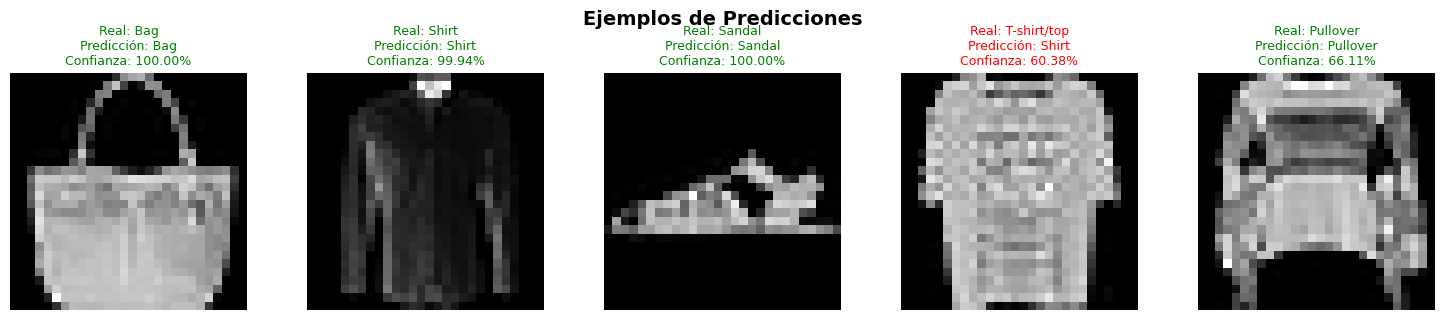


ANÁLISIS DETALLADO DE LA PRIMERA IMAGEN
Etiqueta real: Bag

Probabilidades para cada clase:
--------------------------------------------------
Bag             | ██████████████████████████████████████████████████ | 1.0000
Coat            |                                                    | 0.0000
T-shirt/top     |                                                    | 0.0000
Sneaker         |                                                    | 0.0000
Shirt           |                                                    | 0.0000
Sandal          |                                                    | 0.0000
Pullover        |                                                    | 0.0000
Dress           |                                                    | 0.0000
Ankle boot      |                                                    | 0.0000
Trouser         |                                                    | 0.0000

FUNCIÓN DE EJEMPLO PARA PREDICCIÓN

Ejemplo de uso de la función predecir_i

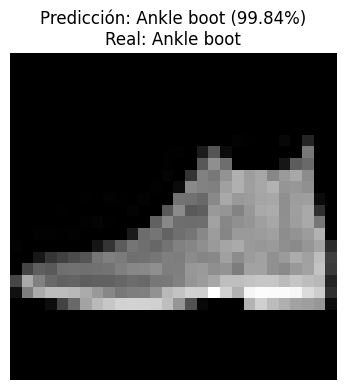

In [7]:
# Predicción con nuevas imágenes (simulación)
print("="*80)
print("HACER PREDICCIONES CON EL MODELO")
print("="*80 + "\n")

# Seleccionar 5 imágenes aleatorias del conjunto de test
indices_ejemplo = np.random.choice(len(X_test), 5, replace=False)
imagenes_ejemplo = X_test[indices_ejemplo]
etiquetas_reales = y_test[indices_ejemplo]

# Normalizar las imágenes
imagenes_normalizadas = imagenes_ejemplo / 255.0

# Hacer predicciones
print("Haciendo predicciones...")
predicciones_ejemplo = model.predict(imagenes_normalizadas, verbose=0)

# Mostrar resultados
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(imagenes_ejemplo[i], cmap='gray')
    
    # Obtener la clase predicha y su probabilidad
    clase_predicha = np.argmax(predicciones_ejemplo[i])
    probabilidad = predicciones_ejemplo[i][clase_predicha]
    clase_real = etiquetas_reales[i]
    
    # Color basado en si es correcto o no
    color = 'green' if clase_predicha == clase_real else 'red'
    
    plt.title(f'Real: {class_names[clase_real]}\n'
              f'Predicción: {class_names[clase_predicha]}\n'
              f'Confianza: {probabilidad:.2%}',
              fontsize=9, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Ejemplos de Predicciones', y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Mostrar las probabilidades detalladas para la primera imagen
print(f"\n{'='*80}")
print(f"ANÁLISIS DETALLADO DE LA PRIMERA IMAGEN")
print(f"{'='*80}")
print(f"Etiqueta real: {class_names[etiquetas_reales[0]]}")
print(f"\nProbabilidades para cada clase:")
print("-" * 50)

# Ordenar clases por probabilidad (de mayor a menor)
probs_ordenadas = np.argsort(predicciones_ejemplo[0])[::-1]

for idx in probs_ordenadas:
    prob = predicciones_ejemplo[0][idx]
    barra = '█' * int(prob * 50)
    print(f"{class_names[idx]:15s} | {barra:50s} | {prob:.4f}")

print(f"{'='*80}")

# Función de ejemplo para usar el modelo con una nueva imagen
print("\n" + "="*80)
print("FUNCIÓN DE EJEMPLO PARA PREDICCIÓN")
print("="*80)

def predecir_imagen(modelo, imagen):
    """
    Predice la clase de una imagen de Fashion MNIST.
    
    Parámetros:
    - modelo: modelo entrenado de Keras
    - imagen: array numpy de forma (28, 28) con valores 0-255
    
    Retorna:
    - clase_predicha: índice de la clase predicha
    - nombre_clase: nombre de la clase predicha
    - probabilidad: probabilidad de la predicción
    - todas_probabilidades: array con probabilidades de todas las clases
    """
    # Normalizar
    imagen_normalizada = imagen / 255.0
    
    # Añadir dimensión batch
    imagen_batch = np.expand_dims(imagen_normalizada, axis=0)
    
    # Predecir
    predicciones = modelo.predict(imagen_batch, verbose=0)
    
    # Obtener resultados
    clase_predicha = np.argmax(predicciones[0])
    probabilidad = predicciones[0][clase_predicha]
    nombre_clase = class_names[clase_predicha]
    
    return clase_predicha, nombre_clase, probabilidad, predicciones[0]

# Ejemplo de uso
print("\nEjemplo de uso de la función predecir_imagen:")
print("-" * 80)

imagen_prueba = X_test[0]
clase_idx, nombre, prob, todas_probs = predecir_imagen(model, imagen_prueba)

print(f"Clase predicha: {nombre} (índice: {clase_idx})")
print(f"Confianza: {prob:.2%}")
print(f"Clase real: {class_names[y_test[0]]}")

# Visualizar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(imagen_prueba, cmap='gray')
plt.title(f'Predicción: {nombre} ({prob:.2%})\nReal: {class_names[y_test[0]]}', 
          fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()